**Импорт библиотек**

In [ ]:
import re
import string
from collections import Counter
import pandas as pd
import spacy
import textstat
import whisper
import os
import numpy as np
from pathlib import Path
import librosa

**Словарь Oxford 5000 с размеченными словами по уровням CEFR**

In [105]:
oxford_dict = pd.read_csv('oxford-5k.csv').set_index('word')['level'].to_dict()

**Импортируем модель spaCy для английского языка**

In [106]:
nlp = spacy.load("en_core_web_sm")

### **Функция для анализа текста**

In [ ]:
def analyze_text(text):
    #предварительная обработка текста
    text_lower = text.lower()
    text = text_lower
    
    #удаляем пунктуацию
    text_clean = text.translate(str.maketrans('', '', string.punctuation))
    words = text_clean.split()
    sentences = re.split(r'[.!?]+', text)
    sentences = [s for s in sentences if s.strip()]

    #1.общее количество слов
    total_words = len(words)

    #2.средняя длина слова
    if total_words > 0:
        avg_word_length = sum(len(word) for word in words) / total_words
    else:
        avg_word_length = 0

    #3.словарный запас (количество уникальных слов)
    unique_words = set(words)
    vocabulary_size = len(unique_words)

    #4.подсчёт слов по уровням
    level_counts = {'a1': 0, 'a2': 0, 'b1': 0, 'b2': 0, 'c1': 0, 'c2': 0}
    for word in words:
        if word in oxford_dict:
            level = oxford_dict[word]
            if level in level_counts:
                level_counts[level] += 1
    
    #вычисляем доли
    if total_words > 0:
        for level in level_counts:
            level_counts[level] = round(level_counts[level] / total_words, 2)

        doc = nlp(text)

    #5.считаем сложные конструкции
    complex_sentences = 0
    passive_constructions = 0

    for sent in doc.sents:
        #признаки сложного предложения (подчинительные союзы, относительные местоимения)
        has_subordinate = any(token.dep_ in ['mark', 'advcl'] for token in sent)
        has_relative = any(token.dep_ == 'relcl' for token in sent)

        if has_subordinate or has_relative:
            complex_sentences += 1

        #пассивный залог
        for token in sent:
            if token.tag_ == 'VBN' and token.head.lemma_ == 'be':
                passive_constructions += 1
    
    #6. анализ типов предложений по конечным знакам
    exclamation_count = text.count('!')
    question_count = text.count('?')
    period_count = text.count('.') - question_count - exclamation_count
    
    #7. анализ пунктуации
    comma_count = text.count(',')
    semicolon_count = text.count(';')
    colon_count = text.count(':')
    dash_count = text.count('-') + text.count('—')
    quote_count = text.count('"') + text.count('"') + text.count("'") + text.count("'")
    parentheses_count = text.count('(') + text.count(')')

    #8.грамматические маркеры сложности
    # Подчинительные союзы
    subordinating_conjunctions = [
        'because', 'although', 'though', 'whereas', 'while', 'since', 
        'if', 'unless', 'when', 'whenever', 'where', 'wherever', 
        'as', 'so that', 'in order that', 'even if', 'even though'
    ]
    
    #сочинительные союзы
    coordinating_conjunctions = ['and', 'but', 'or', 'nor', 'for', 'so', 'yet']
    
    #вводные слова и конструкции
    transition_words = [
        'however', 'therefore', 'moreover', 'furthermore', 'consequently',
        'nevertheless', 'nonetheless', 'accordingly', 'thus', 'hence',
        'in addition', 'on the other hand', 'as a result', 'for example',
        'for instance', 'in particular', 'specifically'
    ]
    
    subordinating_count = sum(1 for conj in subordinating_conjunctions if f' {conj} ' in f' {text} ')
    coordinating_count = sum(1 for conj in coordinating_conjunctions if f' {conj} ' in f' {text} ')
    transition_count = sum(1 for word in transition_words if f' {word} ' in f' {text} ')
    
    #9. относительные местоимения
    relative_pronouns = ['which', 'that', 'who', 'whom', 'whose']
    relative_count = sum(1 for pron in relative_pronouns if f' {pron} ' in f' {text} ')
    
    #10. герундий и инфинитивы
    gerund_count = len(re.findall(r'\b\w+ing\b', text))
    infinitive_count = len(re.findall(r'\bto \w+\b', text))
    
    #11.упрощенный пассивный залог
    passive_markers = ['be', 'am', 'are', 'is', 'was', 'were', 'being', 'been']
    passive_count_simple = 0
    for marker in passive_markers:
        passive_count_simple += len(re.findall(fr'\b{marker} \w+ed\b', text))
        passive_count_simple += len(re.findall(fr'\b{marker} \w+en\b', text))
    
    #12. оценка грамматической сложности
    grammar_complexity_score = (
        (subordinating_count * 0.3) +
        (relative_count * 0.25) +
        (transition_count * 0.2) +
        (passive_count_simple * 0.15) +
        (infinitive_count * 0.05) +
        (gerund_count * 0.05)
    )
    
    #13. нормализованные метрики (на 1000 слов)
    subordinating_density = subordinating_count / total_words * 1000 if total_words > 0 else 0
    coordinating_density = coordinating_count / total_words * 1000 if total_words > 0 else 0
    relative_density = relative_count / total_words * 1000 if total_words > 0 else 0
    transition_density = transition_count / total_words * 1000 if total_words > 0 else 0
    
    #14. доля длинных и коротких предложений
    long_sentences = sum(1 for s in sentences if len(s.split()) > 20)
    short_sentences = sum(1 for s in sentences if len(s.split()) < 5)
    total_sentences = len(sentences) if sentences else 1

    #результаты
    results = {
        'total_words': total_words,
        'avg_word_length': round(avg_word_length, 2),
        'A2_level_words': level_counts['a2'],
        'B1_level_words': level_counts['b1'],
        'B2_level_words': level_counts['b2'],
        'C1_level_words': level_counts['c1'],
        'C2_level_words': level_counts['c2'],
        'vocabulary_size': vocabulary_size,
        'complex_sentence_ratio': complex_sentences / len(list(doc.sents)) if doc.sents else 0,
        'passive_voice_ratio': passive_constructions / total_words if total_words else 0,
        'smog_index': textstat.smog_index(text),
        'coleman_liau_index': textstat.coleman_liau_index(text),
        'sentence_count': textstat.sentence_count(text),
        'lexicon_count': textstat.lexicon_count(text, removepunct=True),
        
        #типы предложений
        'exclamation_sentences': exclamation_count,
        'question_sentences': question_count,
        'declarative_sentences': period_count,
        'long_sentences_ratio': long_sentences / total_sentences if total_sentences > 0 else 0,
        'short_sentences_ratio': short_sentences / total_sentences if total_sentences > 0 else 0,
        
        #пунктуация
        'comma_density': round(comma_count / total_words * 100, 2) if total_words > 0 else 0,
        'semicolon_count': semicolon_count,
        'colon_count': colon_count,
        'dash_count': dash_count,
        'quote_count': quote_count,
        'parentheses_count': parentheses_count,
        
        #грамматические конструкции
        'subordinating_conjunctions': subordinating_count,
        'coordinating_conjunctions': coordinating_count,
        'relative_clauses': relative_count,
        'transition_words': transition_count,
        'gerund_usage': gerund_count,
        'infinitive_usage': infinitive_count,
        'passive_voice_simple': passive_count_simple,
        'subordinating_density': round(subordinating_density, 2),
        'coordinating_density': round(coordinating_density, 2),
        'relative_density': round(relative_density, 2),
        'transition_density': round(transition_density, 2),
        'grammar_complexity_score': round(grammar_complexity_score, 2),
        'has_direct_speech': 1 if quote_count > 0 else 0,
        'has_parentheticals': 1 if parentheses_count > 0 else 0,
    }
    
    return results

### **Функция оценки уровня**

In [ ]:
def estimate_level(results):
    score = 0

    if results['C2_level_words'] >= 0.03:
        score += 2
    elif results['C1_level_words'] >= 0.05:
        score += 1.5
    elif results['B2_level_words'] >= 0.08:
        score += 1
    elif results['B1_level_words'] >= 0.12:
        score += 0.5

    if results.get('complex_sentence_ratio', 0) >= 0.4:
        score += 4
    elif results.get('complex_sentence_ratio', 0) >= 0.25:
        score += 2.5
    elif results.get('complex_sentence_ratio', 0) >= 0.15:
        score += 1
    
    if results.get('passive_voice_ratio', 0) > 0.03:
        score += 1.5
    elif results.get('passive_voice_ratio', 0) > 0.015:
        score += 0.5

    if results.get('subordinating_density', 0) > 20:
        score += 2.5
    elif results.get('subordinating_density', 0) > 12:
        score += 1
    elif results.get('subordinating_density', 0) > 6:
        score += 0.5

    if results.get('relative_density', 0) > 4:
        score += 0.5

    if results.get('transition_density', 0) > 0.5:
        score += 1
    elif results.get('transition_density', 0) > 0.15:
        score += 0.5

    gerund_infinitive = results.get('gerund_usage', 0) + results.get('infinitive_usage', 0)
    if gerund_infinitive > 25:
        score += 1
    elif gerund_infinitive > 20:
        score += 0.5

    grammar_score = results.get('grammar_complexity_score', 0)
    if grammar_score > 5:
        score += 1
    elif grammar_score > 2:
        score += 0.5

    if results['avg_word_length'] > 4.5:
        score += 1.5
    elif results['avg_word_length'] > 3.5:
        score += 0.5

    long_sentences = results.get('long_sentences_ratio', 0)
    if long_sentences > 0.45:
        score += 1.5

    print(f"Итоговый балл: {score}")
    
    #классификация на отдельные уровни CEFR
    if score <= 1.5:
        return "A1"
    elif score <= 5:
        return "A2"
    elif score <= 6.5:
        return "B1"
    elif score <= 7.5:
        return "B2"
    elif score <= 8.5:
        return "C1"
    else:
        return "C2"

### **Блок для транскрибации аудио в текстовый файл**

In [ ]:
def transcribe_audio_to_text(audio_path, model_size="base", output_txt_path=None):

    #проверка существования файла
    if not os.path.exists(audio_path):
        raise FileNotFoundError(f"Аудиофайл не найден: {audio_path}")
    
    #загрузка аудио через librosa
    print(f"Загрузка аудиофайла: {audio_path}")
    try:
        audio, sr = librosa.load(audio_path, sr=16000, mono=True)
        print(f"  Частота: {sr} Гц")
        print(f"  Длительность: {len(audio)/sr:.2f} секунд")
    except Exception as e:
        print(f"Ошибка загрузки аудио: {e}")
        print("Попробуйте установить ffmpeg для поддержки большего числа форматов")
        raise
    
    #загрузка модели Whisper
    model = whisper.load_model(model_size)
    
    #транскрипция аудио
    result = model.transcribe(
        audio,
        language="en",
        task="transcribe",
        verbose=True
    )
    
    text = result["text"]
    
    #сохранение результата в файл
    if output_txt_path is None:
        output_txt_path = str(Path(audio_path).with_suffix('.txt'))
    
    with open(output_txt_path, 'w', encoding='utf-8') as f:
        f.write(text)
    
    return text, output_txt_path

In [ ]:
audio_path = "C:/Users/boss/Documents/Sound Recordings/Recording (3).mp3"
text, txt_path = transcribe_audio_to_text(audio_path, model_size="base")
print(f"Транскрибированный текст:\n{text}")

Загрузка аудиофайла: C:/Users/boss/Documents/Sound Recordings/Recording (3).mp3
  Частота: 16000 Гц
  Длительность: 66.51 секунд
[00:00.000 --> 00:05.000]  Where are you from, Victoria?
[00:05.000 --> 00:10.000]  I'm from Germany, I'm from the North Coast of Germany.
[00:10.000 --> 00:15.000]  And it's a very nice area called the Grand Little Closer Seen in Elm.
[00:15.000 --> 00:17.000]  And I know it.
[00:17.000 --> 00:22.000]  I live in the Capigaw, Lima, near La Coupe.
[00:22.000 --> 00:26.000]  I'd like to tell you something about you.
[00:27.000 --> 00:31.000]  Victoria, how do you like to spend your evenings?
[00:31.000 --> 00:34.000]  If Germany I like to go to my horse,
[00:34.000 --> 00:40.000]  and now I go to the gym or do something else or spend time with my friends.
[00:40.000 --> 00:42.000]  And I do it.
[00:42.000 --> 00:46.000]  Tell us about festival celebration in Peru.
[00:46.000 --> 00:50.000]  Well, I've learned a lot of first year.
[00:50.000 --> 00:53.000]  This

### **Блок для чтения текста из файла**

In [109]:
def read_text_from_file(file_path):
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            text = file.read()
        return text
    except FileNotFoundError:
        print(f"Ошибка: Файл '{file_path}' не найден.")
        return
    except Exception as e:
        print(f"Произошла ошибка при чтении файла: {e}")
        return 
    
file_path = "C:/Users/boss/Documents/examples/C1_example.txt"  # Укажите путь к вашему файлу
text_from_file = read_text_from_file(file_path)

if text_from_file:  # Если файл успешно прочитан
    analysis = analyze_text(text_from_file)
    level = estimate_level(analysis)

    print("Результаты анализа текста из файла:")
    for key, value in analysis.items():
        print(f"{key}: {value}")
    print(f"\nОценочный уровень английского: {level}")


Итоговый балл: 8.0
Результаты анализа текста из файла:
total_words: 612
avg_word_length: 4.46
A2_level_words: 0.1
B1_level_words: 0.05
B2_level_words: 0.05
C1_level_words: 0.01
C2_level_words: 0.0
vocabulary_size: 326
complex_sentence_ratio: 0.5454545454545454
passive_voice_ratio: 0.0032679738562091504
smog_index: 11.715833242495528
coleman_liau_index: 8.778396072013095
sentence_count: 27
lexicon_count: 611
exclamation_sentences: 0
question_sentences: 0
declarative_sentences: 27
long_sentences_ratio: 0.5925925925925926
short_sentences_ratio: 0.037037037037037035
comma_density: 7.03
semicolon_count: 0
colon_count: 0
dash_count: 8
quote_count: 18
parentheses_count: 2
subordinating_conjunctions: 4
coordinating_conjunctions: 4
relative_clauses: 1
transition_words: 0
gerund_usage: 26
infinitive_usage: 14
passive_voice_simple: 0
subordinating_density: 6.54
coordinating_density: 6.54
relative_density: 1.63
transition_density: 0.0
grammar_complexity_score: 3.45
has_direct_speech: 1
has_parenth

*Датасет с размеченными текста по CEFR (cefr_leveled_texts.csv)*

**Функция для анализа текстов из датасета**
- Чтение CSV файла
- Маппинг уровней для сравнения
- Анализ текста (analyze_text)
- Определение уровня и сравнение с правильным ответом
- Сохраняем результаты в results_df

In [ ]:
def analyze_csv_texts(csv_file_path):
    
    #чтение CSV файла
    try:
        df = pd.read_csv(csv_file_path)
    except Exception as e:
        print(f"Ошибка при чтении CSV файла: {e}")
        return None
    
    #список для хранения результатов
    results_list = []

    #анализ каждого текста
    for idx, row in df.iterrows():
        text = row['text']
        real_level = row['label']
        #проверка, что текст не пустой
        if pd.isna(text) or str(text).strip() == '':
            print(f"\nТекст {idx+1}: ПРОПУЩЕН (пустой текст)")
            continue
        
        #анализ текста
        analysis = analyze_text(str(text))
        estimated_level = estimate_level(analysis)
        is_correct = (estimated_level.upper() == real_level.upper())
        
        #сохранение результатов
        results_list.append({
            'text_id': idx + 1,
            'real_level': real_level,
            'estimated_level': estimated_level,
            'is_correct': is_correct,
            **analysis
        })
    
    #сводная статистика
    if results_list:
        
        results_df = pd.DataFrame(results_list)
        
        #общая точность
        accuracy = results_df['is_correct'].mean() * 100
        print(f"\nОбщая точность: {accuracy:.1f}% ({results_df['is_correct'].sum()}/{len(results_df)})")
        
        #точность по уровням
        print("\nТочность по уровням:")
        for level in ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']:
            level_data = results_df[results_df['real_level'].str.upper() == level]
            if len(level_data) > 0:
                level_accuracy = level_data['is_correct'].mean() * 100
                print(f"  {level}: {level_accuracy:.1f}% ({level_data['is_correct'].sum()}/{len(level_data)})")
        
        return results_df
    
    return None

In [139]:
csv_file_path = "C:/Users/boss/Documents/Althaea/hotter than hell/КУРСОВАЯ/project/cefr_leveled_texts.csv"
results_df = analyze_csv_texts(csv_file_path) # ~6 минуты

Итоговый балл: 7.0
Итоговый балл: 9.0
Итоговый балл: 4.5
Итоговый балл: 8.0
Итоговый балл: 6.5
Итоговый балл: 5.5
Итоговый балл: 9.5
Итоговый балл: 6.0
Итоговый балл: 6.0
Итоговый балл: 8.5
Итоговый балл: 6.5
Итоговый балл: 9.0
Итоговый балл: 5.5
Итоговый балл: 7.5
Итоговый балл: 7.0
Итоговый балл: 9.0
Итоговый балл: 6.0
Итоговый балл: 8.0
Итоговый балл: 5.0
Итоговый балл: 3.0
Итоговый балл: 5.0
Итоговый балл: 8.0
Итоговый балл: 4.5
Итоговый балл: 3.5
Итоговый балл: 6.5
Итоговый балл: 8.5
Итоговый балл: 7.0
Итоговый балл: 5.5
Итоговый балл: 7.0
Итоговый балл: 6.5
Итоговый балл: 7.5
Итоговый балл: 4.5
Итоговый балл: 4.0
Итоговый балл: 7.5
Итоговый балл: 6.0
Итоговый балл: 8.5
Итоговый балл: 6.0
Итоговый балл: 5.5
Итоговый балл: 8.0
Итоговый балл: 7.0
Итоговый балл: 8.0
Итоговый балл: 1.5
Итоговый балл: 9.0
Итоговый балл: 5.5
Итоговый балл: 9.5
Итоговый балл: 9.5
Итоговый балл: 7.5
Итоговый балл: 6.5
Итоговый балл: 9.0
Итоговый балл: 7.5
Итоговый балл: 7.5
Итоговый балл: 7.5
Итоговый бал

**Вывод, сколько верно и неверно определённых текстов**

In [121]:
if results_df is not None:
    correct = (results_df['estimated_level'] == results_df['real_level']).sum()
    incorrect = (results_df['estimated_level'] != results_df['real_level']).sum()
    total = len(results_df)

    print(f"\nРезультаты:")
    print(f"Правильно: {correct}/{total} ({correct/total*100:.1f}%)")
    print(f"Неправильно: {incorrect}/{total} ({incorrect/total*100:.1f}%)")


Результаты:
Правильно: 671/1494 (44.9%)
Неправильно: 823/1494 (55.1%)


# Графики

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter
import os

C:\Users\boss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\boss\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


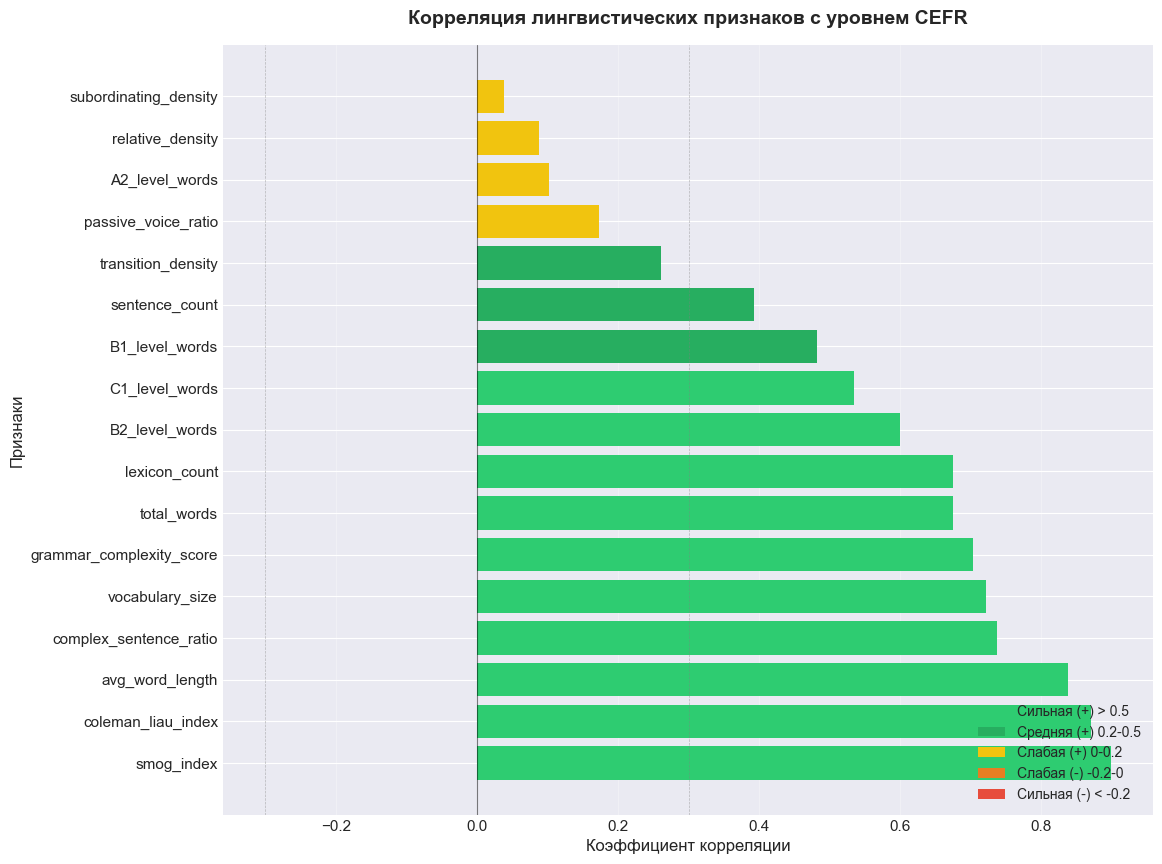

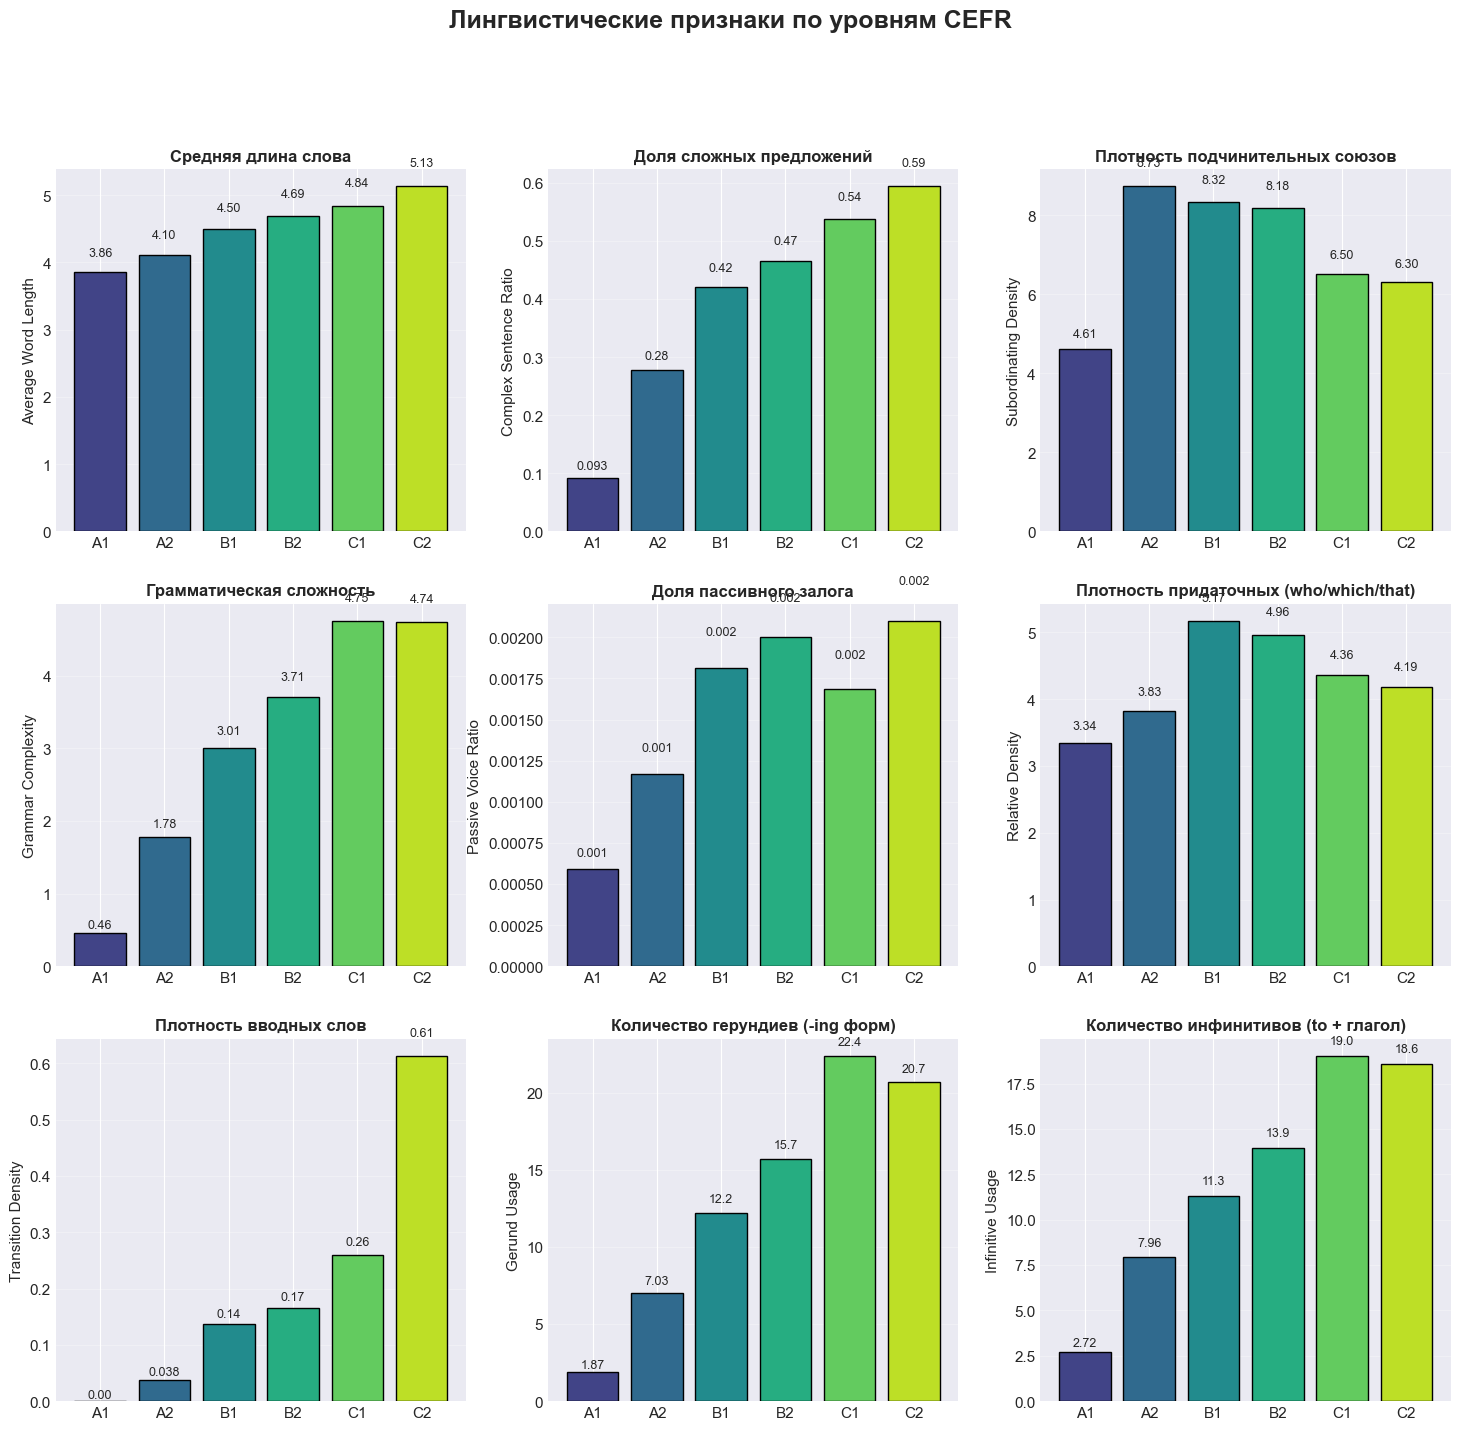

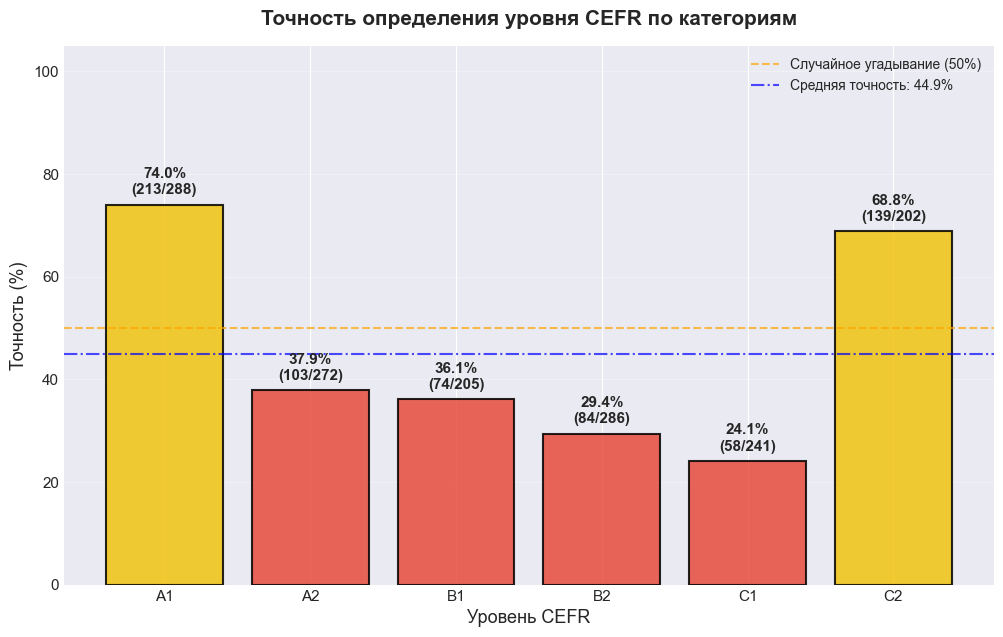

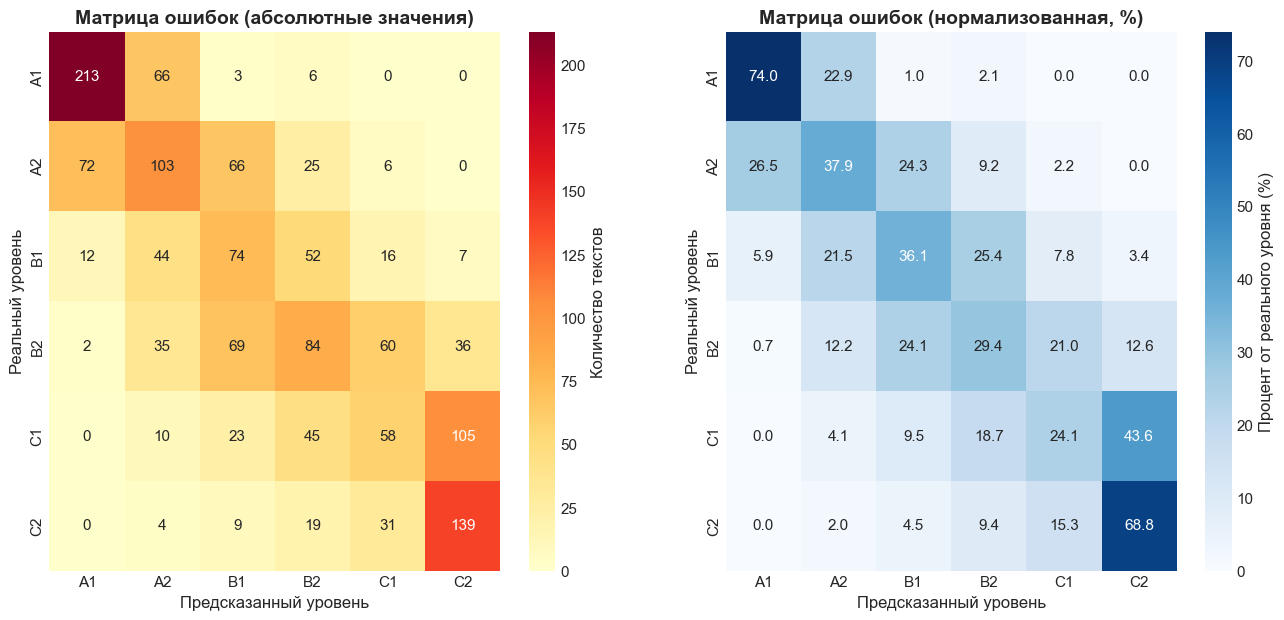

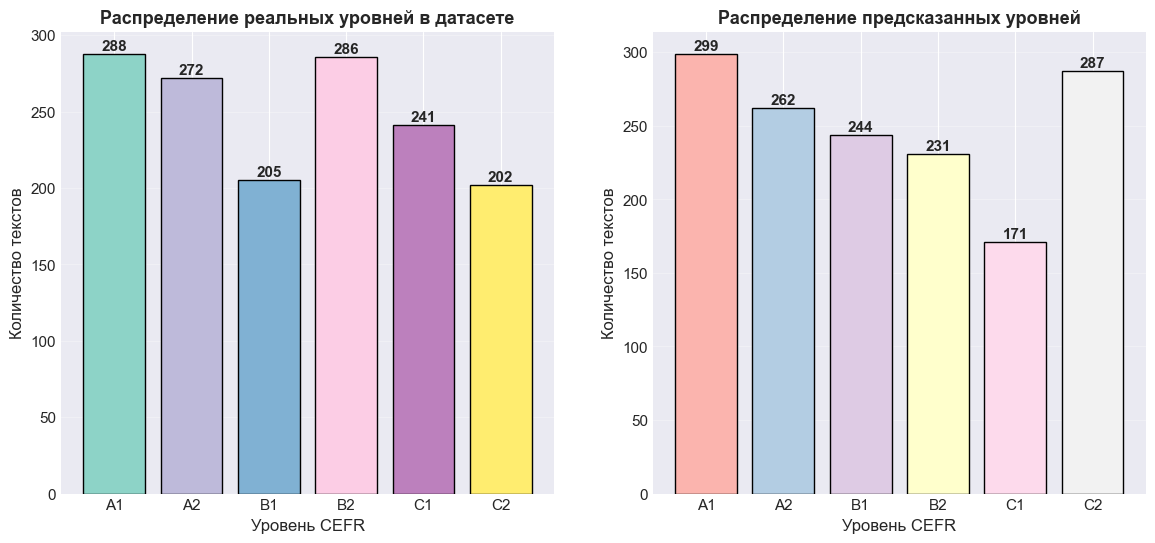

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 10

output_dir = 'analysis_plots'
os.makedirs(output_dir, exist_ok=True)

if results_df is not None:

    #1. КОРРЕЛЯЦИЯ ПРИЗНАКОВ С УРОВНЕМ CEFR
    #преобразуем реальные уровни в числовые значения
    cefr_numeric_mapping = {'A1': 1, 'A2': 2, 'B1': 3, 'B2': 4, 'C1': 5, 'C2': 6}
    results_df['cefr_numeric'] = results_df['real_level'].map(cefr_numeric_mapping)
    
    #признаки для анализа корреляции
    feature_columns = [
        'total_words', 'avg_word_length', 
        'A2_level_words', 'B1_level_words', 
        'B2_level_words', 'C1_level_words', 'C2_level_words',
        'vocabulary_size',
        'complex_sentence_ratio', 'passive_voice_ratio',
         'smog_index', 'coleman_liau_index',
        'sentence_count', 'lexicon_count',
        # Новые метрики
        'subordinating_density', 'relative_density', 'transition_density',
        'grammar_complexity_score'
    ]
    
    #вычисляем корреляцию
    correlations = {}
    for feature in feature_columns:
        if feature in results_df.columns:
            corr_val = results_df[feature].corr(results_df['cefr_numeric'])
            if not pd.isna(corr_val):
                correlations[feature] = corr_val
    
    #создаем DataFrame с корреляциями
    corr_df = pd.DataFrame(list(correlations.items()), 
                           columns=['Feature', 'Correlation_with_CEFR'])
    corr_df = corr_df.sort_values('Correlation_with_CEFR', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 10))
    colors = []
    for corr in corr_df['Correlation_with_CEFR']:
        if corr > 0.5:
            colors.append('#2ecc71')  
        elif corr > 0.2:
            colors.append('#27ae60') 
        elif corr > 0:
            colors.append('#f1c40f')  
        elif corr > -0.2:
            colors.append('#e67e22') 
        else:
            colors.append('#e74c3c') 
    
    bars = ax.barh(corr_df['Feature'], corr_df['Correlation_with_CEFR'], color=colors)
    
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax.axvline(x=0.3, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.axvline(x=-0.3, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    
    ax.set_xlabel('Коэффициент корреляции', fontsize=12)
    ax.set_ylabel('Признаки', fontsize=12)
    ax.set_title('Корреляция лингвистических признаков с уровнем CEFR', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)

    legend_elements = [
        Patch(facecolor='#2ecc71', label='Сильная (+) > 0.5'),
        Patch(facecolor='#27ae60', label='Средняя (+) 0.2-0.5'),
        Patch(facecolor='#f1c40f', label='Слабая (+) 0-0.2'),
        Patch(facecolor='#e67e22', label='Слабая (-) -0.2-0'),
        Patch(facecolor='#e74c3c', label='Сильная (-) < -0.2')
    ]
    ax.legend(handles=legend_elements, loc='lower right')

    plt.savefig(os.path.join(output_dir, 'correlation_analysis.png'), dpi=300, bbox_inches='tight')
    
    #2. СРАВНЕНИЕ ПРИЗНАКОВ ПО УРОВНЯМ (расширенная сетка)
    fig, axes = plt.subplots(3, 3, figsize=(18, 16))
    fig.suptitle('Лингвистические признаки по уровням CEFR', 
            fontsize=18, fontweight='bold', y=0.98)

    visualization_features = [
        ('avg_word_length', 'Average Word Length', 'Средняя длина слова', '#3498db'),
        ('complex_sentence_ratio', 'Complex Sentence Ratio', 'Доля сложных предложений', '#9b59b6'),
        ('subordinating_density', 'Subordinating Density', 'Плотность подчинительных союзов', '#f39c12'),
        ('grammar_complexity_score', 'Grammar Complexity', 'Грамматическая сложность', '#1abc9c'),
        ('passive_voice_ratio', 'Passive Voice Ratio', 'Доля пассивного залога', '#e67e22'),
        ('relative_density', 'Relative Density', 'Плотность придаточных (who/which/that)', '#e84393'),
        ('transition_density', 'Transition Density', 'Плотность вводных слов', '#fd79a8'),
        ('gerund_usage', 'Gerund Usage', 'Количество герундиев (-ing форм)', '#00b894'),
        ('infinitive_usage', 'Infinitive Usage', 'Количество инфинитивов (to + глагол)', '#0984e3')
    ]

    for idx, (feature, eng_name, rus_name, color) in enumerate(visualization_features):
        row, col = idx // 3, idx % 3
        ax = axes[row, col]
    
        if feature in results_df.columns:
            feature_by_level = results_df.groupby('real_level')[feature].mean().reindex(['A1','A2','B1','B2','C1','C2'])
            colors_grad = plt.cm.viridis(np.linspace(0.2, 0.9, len(feature_by_level)))
            bars = ax.bar(range(len(feature_by_level)), feature_by_level.values, color=colors_grad, edgecolor='black', linewidth=1)
        
            ax.set_xticks(range(len(feature_by_level)))
            ax.set_xticklabels(feature_by_level.index, fontsize=11)
            ax.set_ylabel(eng_name, fontsize=11)
            ax.set_title(rus_name, fontsize=12, fontweight='bold')
            ax.grid(axis='y', alpha=0.3)
        
            for bar, v in zip(bars, feature_by_level.values):
                if v < 0.1 and v > 0:
                    ax.text(bar.get_x() + bar.get_width()/2, v + v*0.1, 
                        f'{v:.3f}', ha='center', va='bottom', fontsize=9)
                elif v >= 10:
                    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, 
                        f'{v:.1f}', ha='center', va='bottom', fontsize=9)
                else:
                    ax.text(bar.get_x() + bar.get_width()/2, v + v*0.05, 
                        f'{v:.2f}', ha='center', va='bottom', fontsize=9)

    plt.savefig(os.path.join(output_dir, 'features_by_level.png'), dpi=300, bbox_inches='tight')
    
    # 3. ТОЧНОСТЬ ПО УРОВНЯМ
    #вычисление точности
    accuracy_by_level = []
    for level in ['A1', 'A2', 'B1', 'B2', 'C1', 'C2']:
        level_data = results_df[results_df['real_level'] == level]
        if len(level_data) > 0:
            correct = (level_data['estimated_level'] == level).sum()
            total = len(level_data)
            accuracy = (correct / total) * 100
            accuracy_by_level.append({'level': level, 'accuracy': accuracy, 'correct': correct, 'total': total})
    
    accuracy_df = pd.DataFrame(accuracy_by_level)
    
    fig, ax = plt.subplots(figsize=(12, 7))
    
    bar_colors = []
    for acc in accuracy_df['accuracy']:
        if acc >= 80:
            bar_colors.append('#2ecc71')
        elif acc >= 60:
            bar_colors.append('#f1c40f')
        elif acc >= 40:
            bar_colors.append('#e67e22')
        else:
            bar_colors.append('#e74c3c')
    
    bars = ax.bar(accuracy_df['level'], accuracy_df['accuracy'], color=bar_colors, 
                  edgecolor='black', linewidth=1.5, alpha=0.85)
    
    for bar, acc, corr, total in zip(bars, accuracy_df['accuracy'], 
                                      accuracy_df['correct'], accuracy_df['total']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{acc:.1f}%\n({corr}/{total})', 
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.set_xlabel('Уровень CEFR', fontsize=13)
    ax.set_ylabel('Точность (%)', fontsize=13)
    ax.set_title('Точность определения уровня CEFR по категориям', 
                 fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, 105)
    ax.axhline(y=50, color='orange', linestyle='--', alpha=0.7, label='Случайное угадывание (50%)')
    ax.axhline(y=results_df['is_correct'].mean() * 100, color='blue', 
               linestyle='-.', alpha=0.7, label=f"Средняя точность: {results_df['is_correct'].mean()*100:.1f}%")
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper right')

    plt.savefig(os.path.join(output_dir, 'accuracy_by_level.png'), dpi=300, bbox_inches='tight')
    
    # 4. МАТРИЦА ОШИБОК (улучшенная тепловая карта)    
    #создание матрицы ошибок
    confusion_matrix = pd.crosstab(
        results_df['real_level'],
        results_df['estimated_level'],
        rownames=['Реальный уровень'],
        colnames=['Предсказанный уровень']
    )
    
    #нормализованная матрица ошибок
    confusion_matrix_norm = confusion_matrix.div(confusion_matrix.sum(axis=1), axis=0) * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    #абсолютные значения
    sns.heatmap(confusion_matrix, annot=True, fmt='d', cmap='YlOrRd', 
                xticklabels=True, yticklabels=True, ax=ax1,
                cbar_kws={'label': 'Количество текстов'})
    ax1.set_title('Матрица ошибок (абсолютные значения)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Предсказанный уровень', fontsize=12)
    ax1.set_ylabel('Реальный уровень', fontsize=12)
    
    #нормализованные значения в процентах
    sns.heatmap(confusion_matrix_norm, annot=True, fmt='.1f', cmap='Blues', 
                xticklabels=True, yticklabels=True, ax=ax2,
                cbar_kws={'label': 'Процент от реального уровня (%)'})
    ax2.set_title('Матрица ошибок (нормализованная, %)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Предсказанный уровень', fontsize=12)
    ax2.set_ylabel('Реальный уровень', fontsize=12)

    plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'), dpi=300, bbox_inches='tight')
    
    # 5. РАСПРЕДЕЛЕНИЕ ОЦЕНОК ПО УРОВНЯМ    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    real_counts = results_df['real_level'].value_counts().sort_index()
    colors = plt.cm.Set3(np.linspace(0, 1, len(real_counts)))
    bars1 = ax1.bar(real_counts.index, real_counts.values, color=colors, edgecolor='black', linewidth=1)
    ax1.set_title('Распределение реальных уровней в датасете', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Уровень CEFR', fontsize=12)
    ax1.set_ylabel('Количество текстов', fontsize=12)
    ax1.grid(axis='y', alpha=0.3)
    for bar, (level, count) in zip(bars1, real_counts.items()):
        ax1.text(bar.get_x() + bar.get_width()/2, count + 0.5, 
                str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    pred_counts = results_df['estimated_level'].value_counts().sort_index()
    colors = plt.cm.Pastel1(np.linspace(0, 1, len(pred_counts)))
    bars2 = ax2.bar(pred_counts.index, pred_counts.values, color=colors, edgecolor='black', linewidth=1)
    ax2.set_title('Распределение предсказанных уровней', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Уровень CEFR', fontsize=12)
    ax2.set_ylabel('Количество текстов', fontsize=12)
    ax2.grid(axis='y', alpha=0.3)
    for bar, (level, count) in zip(bars2, pred_counts.items()):
        ax2.text(bar.get_x() + bar.get_width()/2, count + 0.5, 
                str(count), ha='center', va='bottom', fontsize=11, fontweight='bold')
    plt.savefig(os.path.join(output_dir, 'level_distribution.png'), dpi=300, bbox_inches='tight')